<br/>

<div align="center">
<span style="font-size: 2.5em;">SBI Training Results and Inference</span>
<br/>
<span style="font-size: 1.2em; color: gray;">Visualization of trained S1S2 models and posterior inference</span>
</div>

## Overview

This notebook visualizes the training results and demonstrates inference capabilities of trained SBI models for WIMP parameter estimation using S1S2 histogram data.

**Workflow:**

1. **Setup**: Load trained model and prepare datasets
2. **Training Analysis**: Visualize loss and accuracy curves from training
3. **Single Posterior**: Generate and plot posterior for a specific parameter combination
4. **Grid Posteriors**: Generate posteriors across a grid of parameter values

## 1. Setup and Configuration

Import required libraries and set up paths to access the project modules.

In [1]:
import os
desired_root_name = "xenon-sbi" 
while os.path.basename(os.getcwd()) != desired_root_name:
    os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))

import torch
import numpy as np

from configs.config import load_model_s1s2, PARAM_RANGES
from utils.training import plot_training_summary
from utils.posteriors import (
    plot_posterior_single_s1s2, 
    plot_posterior_grid_s1s2,
    plot_null_exclusion_s1s2,
 )
from utils.processing import load_s1s2_valloader

### Model and Data Configuration

Specify the model architecture, data regime, training configuration, and plotting settings.

In [2]:
# --- Model and data settings ---
modelname = "S1S2_signal"
halo      = "shm"
datatag   = "low"
n_train   = 300_000
bins      = 10

# Background settings
mu_bg = 0  

# Evaluation settings
n_eval = 5000  # lighter subsample for evaluation

logm_range = PARAM_RANGES[datatag]["logm_range"]
logcp_range = PARAM_RANGES[datatag]["logcp_range"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Load Trained Model

Load the pre-trained model from checkpoint and display architecture.

In [3]:
signal_type = "signal_only" if mu_bg == 0 else f"signal_bg_mu{mu_bg:.0f}"
SIGNAL_PT = f"data/datasets/xenon/s1s2/pt/s1s2_n{n_train}_{halo}.pt"
bg_CSV = "data/datasets/xenon/s1s2/ers/s1s2_ers.csv"
MODELPATH = f"models/xenon/{signal_type}/{halo}/{modelname}_bins{bins}_n{n_train}_{halo}.pt"
print(f"Loading model from:\n{MODELPATH}\n")

model, ckpt = load_model_s1s2(MODELPATH, bins=bins, modelname=modelname, device=device, print_arch=True)

Loading model from:
models/xenon/signal_only/shm/S1S2_signal_bins10_n300000_shm.pt

S1S2_signal(
  (net): Sequential(
    (0): Linear(in_features=102, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): SiLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): SiLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=128, out_features=128, bias=True)
    (13): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): SiLU()
    (15): Dropout(p=0.1, inplace=False)
    (16): Linear(in_features=128, out_features=1

### Prepare Dataset

Load the dataset and create validation dataloader for inference tasks.

In [4]:
val_loader, bg_events = load_s1s2_valloader(SIGNAL_PT, bg_CSV, mu_bg=mu_bg, bins=bins, n_eval=n_eval)

Validation pairs: 10,000


## 2. Training Analysis

Visualize the training history to assess model convergence and performance.


Training Summary
────────────────────────────────────────────
Best validation loss:     0.419
Best validation accuracy: 0.771
────────────────────────────────────────────


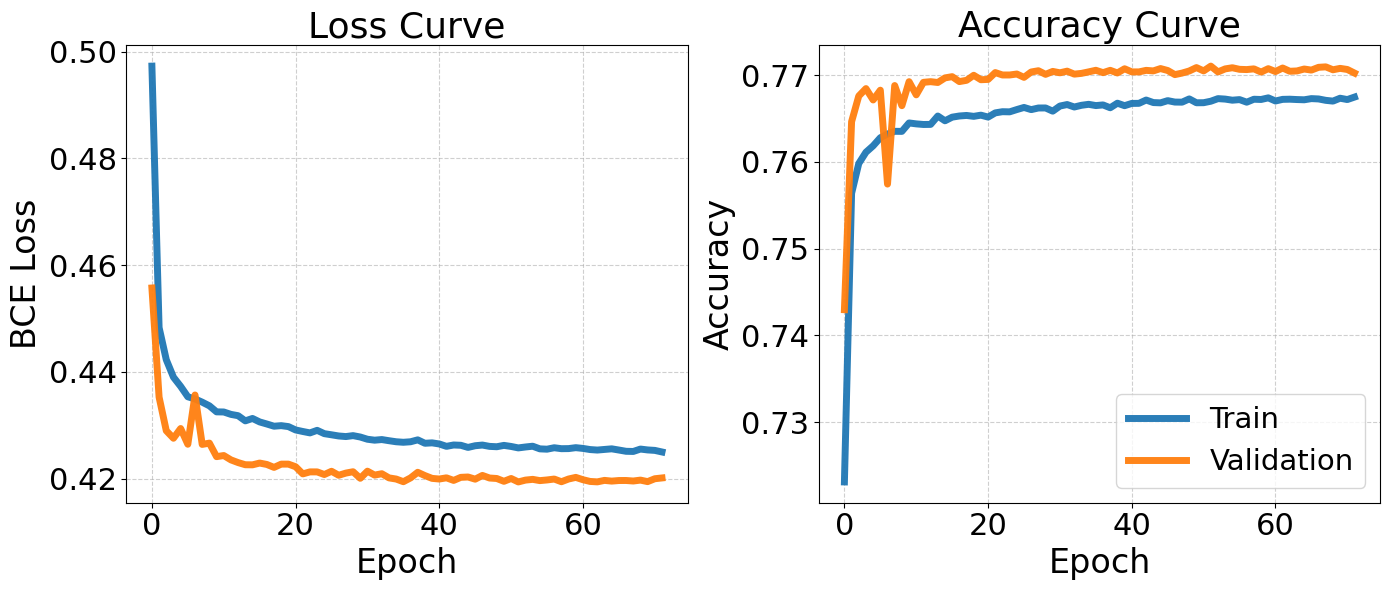

In [5]:
plot_training_summary(ckpt)

### Understanding Training vs Validation Loss

**Note:** It's normal for validation loss to be lower than training loss in this setup. This occurs because:

1. **Dropout (5%)**: Randomly disables neurons during training, adding noise and making training harder. Disabled during validation.
2. **Batch Normalization**: Uses batch statistics during training but running averages during validation, leading to more stable predictions.
3. **Model Modes**: `model.train()` enables regularization, while `model.eval()` disables it for more consistent inference.

This is a **sign of good regularization** working properly, not a problem. The model isn't overfitting and generalizes well to unseen data. Only worry if the gap becomes very large (>30%) or if validation loss increases over time.

## 3. Posterior Inference

Demonstrate inference capabilities by generating posterior distributions for given parameter combinations.

### Single Posterior Example

Load a spectrum for a specific WIMP mass and cross-section combination.

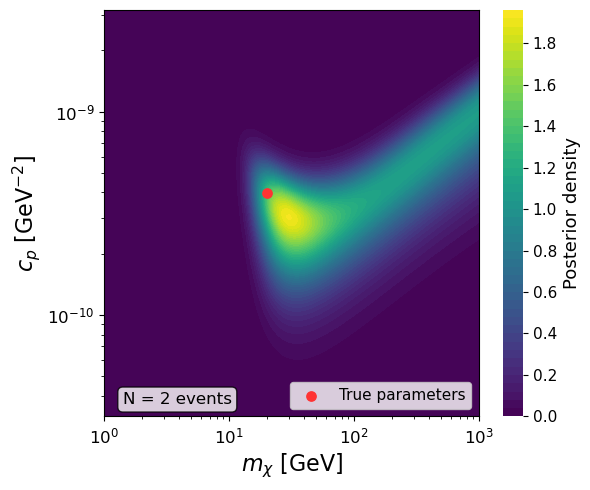

In [6]:
plot_posterior_single_s1s2(
    model=model,
    val_loader=val_loader,
    mchi=20.0,
    cp=10**(-9.4),
    #credible_levels=[0.68, 0.95],
    y_quantity="cp"
 )

### Grid of Posteriors

Generate multiple posteriors across a grid of parameter values to visualize how the model performs across different regions of parameter space.

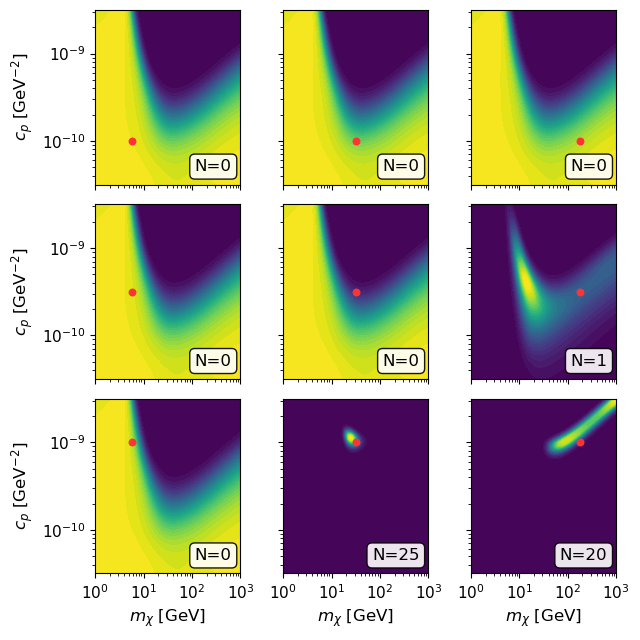

In [7]:
plot_posterior_grid_s1s2(
    model=model,
    val_loader=val_loader, 
    grid_dim=3, 
    #save_path=f"figures/...",
 )

## 4. HPD Credible-Region Exclusions

Use highest-posterior-density (HPD) credible regions to define exclusion curves.
This method finds the smallest-area region containing a given probability mass and extracts the boundary as an exclusion line.

### HPD Exclusion from Null Spectrum

Compute the HPD-based exclusion curve directly from the null posterior.

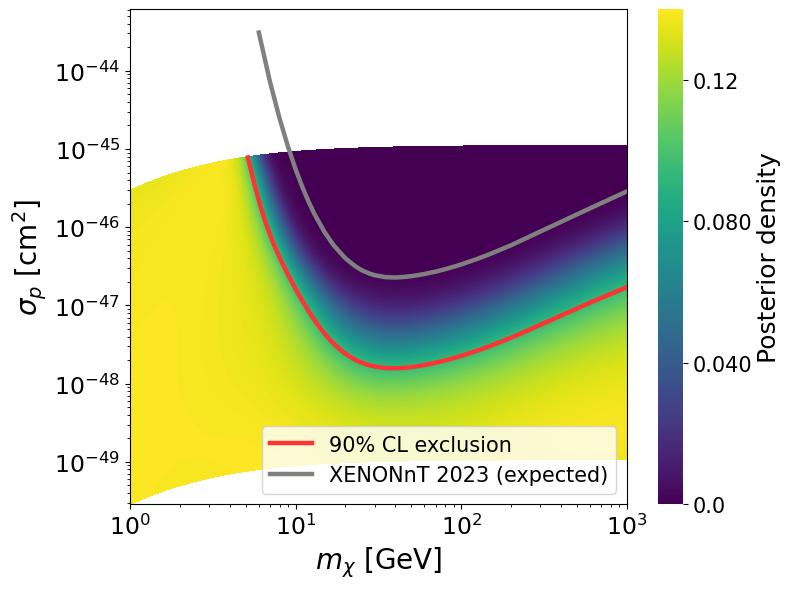

In [8]:
plot_null_exclusion_s1s2(
    model=model,
    background_events=bg_events,
    mu_bg=mu_bg,
    bins=bins,
    plot_official_xenonnt=True,
    y_quantity="sigma",
    #save_path=f"figures/...",
 )